# Work Rate Limited Variable Duration Pendulum Swing Up

The positive work done by the torque input is calculated using a soft plus
function to avoid non-smoothness that would arise from using a standard max.

In this example, the goal is to put a limit on the work that can be done in 2 seconds.


In [1]:
import os
import numpy as np
import sympy as sm
from opty import Problem
import matplotlib.pyplot as plt
import matplotlib.animation as animation

### Start with defining the fixed duration and number of nodes.

In [2]:
target_angle = np.pi
num_nodes = 501

### Symbolic equations of motion

$W$ is the total positive work done by the torque input. So negative power or braking is ignored as an extra challenge. (For this particular problem the power seems to never get negative but I will leave this equation in place to potential problems that it could cause) Its derivative is given by the equation:

$$ \frac{d}{dt} W= \frac{1}{s}  \ln(e^{s P(t)} + 1) \approx \max(0, P(t))$$
$$ P(t) = T(t) \omega(t)$$

Which comes with a sharpness factor, $s$, to tune how tight the bend is of the softplus function.

$W_{delay}(t)$ Is a copy of $W$ with a delay of `time_delay` = 2 seconds.

$W_{diff}(t)$ is the amount of energy that is used in the last 2 seconds.
$$W_{diff}(t) = W(t) - W_{delay}(t)$$

In [3]:
m, g, d, t, h = sm.symbols("m, g, d, t, h", real=True)
theta, omega, T, W, W_delay, Wdt_delay, W_diff = sm.symbols(
    "theta, omega, T, W, Wdelay, Wdtdelay, Wdiff", cls=sm.Function
)
P = T(t) * omega(t)  # Power

sharpness = 10.0 # define how tight the softplus function is
# Softplus demo available at: https://www.desmos.com/calculator/sveirxlszn
Wdt_func = 1 / sharpness * sm.ln(sm.exp(sharpness * (T(t) * omega(t))) + 1)
Wdt_numeric = sm.lambdify((T(t), omega(t)), Wdt_func, "numpy")

state_symbols = (theta(t), omega(t), W(t), W_diff(t))
constant_symbols = (m, g, d)
specified_symbols = (T(t),)

free_order = [theta(t), omega(t), W(t), W_diff(t), T(t), Wdt_delay(t), h]

eom = sm.Matrix(
    [
        theta(t).diff() - omega(t),
        m * d**2 * omega(t).diff() + m * g * d * sm.sin(theta(t)) - T(t),
        W(t).diff() - Wdt_func,
        W_diff(t).diff() - (Wdt_func - Wdt_delay(t)),
    ]
)
eom

Matrix([
[                                         -omega(t) + Derivative(theta(t), t)],
[                 d**2*m*Derivative(omega(t), t) + d*g*m*sin(theta(t)) - T(t)],
[                 -0.1*log(exp(10.0*T(t)*omega(t)) + 1) + Derivative(W(t), t)],
[Wdtdelay(t) - 0.1*log(exp(10.0*T(t)*omega(t)) + 1) + Derivative(Wdiff(t), t)]])

Specify the known system parameters.

In [4]:
par_map = {
    m: 1.0,
    g: 9.81,
    d: 1.0,
}
time_delay = 2.0  # seconds

Known trajectories are used for the calculation of the delayed signals. 

`delaydt_traj(free)`:
In order to calculate the delayed version of the derivative, first the undelayed derivative of $W(t)$ needs to be calculated (`Wdt` is not a state variable and thus not accesible in `free`). The values of torque $T(t)$ and rotational velocity $\omega(t)$ can be grabbed from the free vector for this calculation.

In [5]:
def delay_traj(free):
    time = np.linspace(0, free[-1] * (num_nodes - 1), num_nodes)
    delayed_time = np.clip(time - time_delay, 0, None)
    W_index = free_order.index(W(t))
    W_arr = free[W_index * num_nodes : (W_index + 1) * num_nodes]
    w_delay = np.interp(delayed_time, time, W_arr)
    return w_delay


def delaydt_traj(free):
    time = np.linspace(0, free[-1] * (num_nodes - 1), num_nodes)
    delayed_time = np.clip(time - time_delay, 0, None)
    T_index = free_order.index(T(t))
    omega_index = free_order.index(omega(t))
    T_arr = free[T_index * num_nodes : (T_index + 1) * num_nodes]
    omega_arr = free[omega_index * num_nodes : (omega_index + 1) * num_nodes]
    wdt = Wdt_numeric(T_arr, omega_arr)
    wdt_delay = np.interp(delayed_time, time, wdt)
    return wdt_delay

Specify the objective function and it's gradient. In this case, make the problem instance the first argument and it is available to use inside the these functions. This shows how to use ``.parse_free()``, ``.extract_values()``, and ``.fill_free()`` to manage the numerical vectors.


In [6]:
def obj(prob, free):
    """Minimize the sum of the squares of the control torque."""
    T_vals = prob.extract_values(free, T(t))
    h_val = prob.extract_values(free, h)
    return h_val * np.sum(T_vals**2)


def obj_grad(prob, free):
    T_vals = prob.extract_values(free, T(t))
    h_val = prob.extract_values(free, h)
    grad = np.zeros_like(free)
    prob.fill_free(grad, 2.0 * h_val * T_vals, T(t))
    prob.fill_free(grad, np.sum(T_vals**2), h)
    return grad

Specify the symbolic instance constraints, i.e. initial and end conditions using node numbers 0 to N - 1

In [7]:
instance_constraints = (
    theta(0 * h),
    theta((num_nodes - 1) * h) - target_angle,
    omega(0 * h),
    omega((num_nodes - 1) * h),
    W(0 * h),
    W_diff(0 * h),
)

Specify the variable bounds for each state and input.

In [8]:
bounds = {
    T(t): (-2.0, 2.0),
    W(t): (0, np.inf),
    h: (0.0, 0.5),
}

Create an optimization problem. If the backend is set to ``numpy``, no C compiler is needed and the problem can be solved using pure Python code. There is a large performance loss but for simple problems performance may not be a concern.

In [9]:
prob = Problem(
    obj,
    obj_grad,
    eom,
    state_symbols,
    num_nodes,
    h,
    known_parameter_map=par_map,
    instance_constraints=instance_constraints,
    time_symbol=t,
    bounds=bounds,
    known_trajectory_map={
        W_delay(t): delay_traj,
        W_delay(t).diff(t): delaydt_traj,
    },
    backend="numpy",
)

Use existing solution if available else pick a reasonable initial guess and solve the problem. Use approximately zero as an initial guess to avoid divide-by-zero, and solve the problem.

In [10]:
fname = f"pendulum_swing_up_variable_duration_{num_nodes}_nodes_solution.csv"
if os.path.exists(fname):
    solution = np.loadtxt(fname)
else:
    initial_guess = np.full(prob.num_free, 1e-10)
    solution, info = prob.solve(initial_guess)
    print(info["status_msg"])
    print(info["obj_val"])

b'Algorithm terminated successfully at a locally optimal point, satisfying the convergence tolerances (can be specified by options).'
23.016107910289318


In [11]:
np.savetxt(fname, solution)

Plot the optimal state and input trajectories.

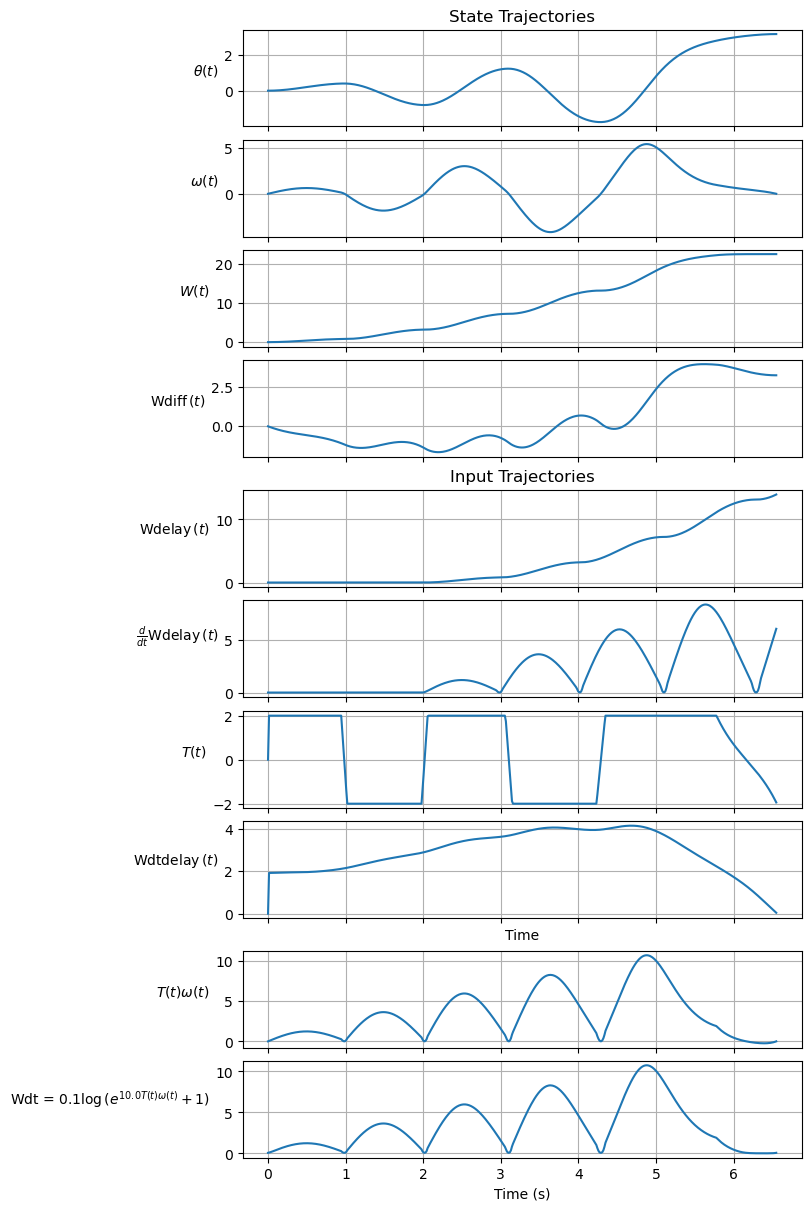

In [12]:
T_vals = prob.extract_values(solution, T(t))
omega_vals = prob.extract_values(solution, omega(t))
time_vals = prob.time_vector(solution)
power_vals = T_vals * omega_vals
power_vals_rect = Wdt_numeric(T_vals, omega_vals)

fig, axes = plt.subplots(10, 1, figsize=(8, 12), sharex=True, layout="compressed")
axes = axes.flatten()

_ = prob.plot_trajectories(solution, axes)

power_ax = axes[8]
power_ax.plot(time_vals, power_vals)
power_ax.set_ylabel(sm.latex(P, mode="inline"))

power_ax2 = axes[9]
power_ax2.plot(time_vals, power_vals_rect)
power_ax2.set_ylabel("Wdt = " + sm.latex(Wdt_func, mode="inline"))

for ax in axes:
    ax.grid()
    ax.set_ylabel(ax.get_ylabel(), rotation="horizontal", ha="right")

axes[-1].set_xlabel("Time (s)")

plt.show()

Plot the constraint violations.

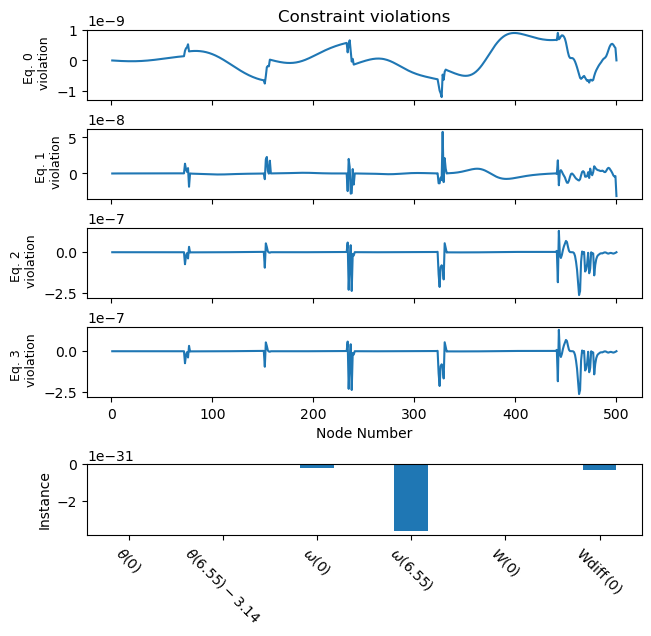

In [13]:
_ = prob.plot_constraint_violations(solution, subplots=True)

In [14]:
print(list(prob._extraction_indices.keys()))
print(free_order)

[theta(t), omega(t), W(t), Wdiff(t), T(t), Wdtdelay(t), h]
[theta(t), omega(t), W(t), Wdiff(t), T(t), Wdtdelay(t), h]
